<a href="https://colab.research.google.com/github/Manasa23BEIS123/AIML-12-Week-Program/blob/feat%2Faiml-W2-Manasa/W2D2_Feature_Scaling_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create a sample dataset

data = {
    "Study_Hours": [2, 5, 3, 8, 6, 1, 7, 4, 9, 2, 6, 5, 3, 8, 7],
    "Attendance": [60, 85, 70, 95, 90, 55, 92, 75, 98, 65, 88, 82, 72, 94, 91],
    "Age": [18, 19, 18, 20, 19, 18, 21, 19, 20, 18, 21, 20, 19, 22, 21],
    "Gender": [
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female"
    ],
    "Department": [
        "CSE", "ECE", "CSE", "EEE", "CSE",
        "ECE", "EEE", "CSE", "ECE", "EEE",
        "CSE", "ECE", "EEE", "CSE", "ECE"
    ],
    "Performance": [
        "Average", "Good", "Average", "Excellent", "Good",
        "Poor", "Excellent", "Good", "Excellent", "Average",
        "Good", "Good", "Average", "Excellent", "Good"
    ],
    "Passed": [0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (15, 7)


,Study_Hours,Attendance,Age,Gender,Department,Performance,Passed
0,2,60,18,Female,CSE,Average,0
1,5,85,19,Male,ECE,Good,1
2,3,70,18,Female,CSE,Average,0
3,8,95,20,Male,EEE,Excellent,1
4,6,90,19,Female,CSE,Good,1


In [3]:
# Label Encoding

label_encoder = LabelEncoder()

df["Gender_LabelEncoded"] = label_encoder.fit_transform(df["Gender"])

print("Label Encoding:")
print(df[["Gender", "Gender_LabelEncoded"]].head(10))


Label Encoding:
   Gender  Gender_LabelEncoded
0  Female                    0
1    Male                    1
2  Female                    0
3    Male                    1
4  Female                    0
5    Male                    1
6  Female                    0
7    Male                    1
8  Female                    0
9    Male                    1


In [4]:
# One-Hot Encoding

onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

department_encoded = onehot_encoder.fit_transform(
    df[["Department"]]
)

department_encoded_df = pd.DataFrame(
    department_encoded,
    columns=onehot_encoder.get_feature_names_out(["Department"])
)

print("One-Hot Encoded Data:")
display(department_encoded_df.head())

One-Hot Encoded Data:


,Department_CSE,Department_ECE,Department_EEE
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0


In [5]:
# Ordinal Encoding

ordinal_encoder = OrdinalEncoder(
    categories=[["Poor", "Average", "Good", "Excellent"]]
)

df["Performance_OrdinalEncoded"] = ordinal_encoder.fit_transform(
    df[["Performance"]]
)

print("Ordinal Encoding:")
display(df[["Performance", "Performance_OrdinalEncoded"]].head(10))

Ordinal Encoding:


,Performance,Performance_OrdinalEncoded
0,Average,1.0
1,Good,2.0
2,Average,1.0
3,Excellent,3.0
4,Good,2.0
5,Poor,0.0
6,Excellent,3.0
7,Good,2.0
8,Excellent,3.0
9,Average,1.0


In [6]:
# Select numerical features

numerical_features = ["Study_Hours", "Attendance", "Age"]

print("Original Numerical Features:")
display(df[numerical_features].describe())

Original Numerical Features:


,Study_Hours,Attendance,Age
count,15.000000,15.000000,15.000000
mean,5.066667,80.800000,19.533333
std,2.491892,13.712351,1.302013
min,1.000000,55.000000,18.000000
25%,3.000000,71.000000,18.500000
50%,5.000000,85.000000,19.000000
75%,7.000000,91.500000,20.500000
max,9.000000,98.000000,22.000000


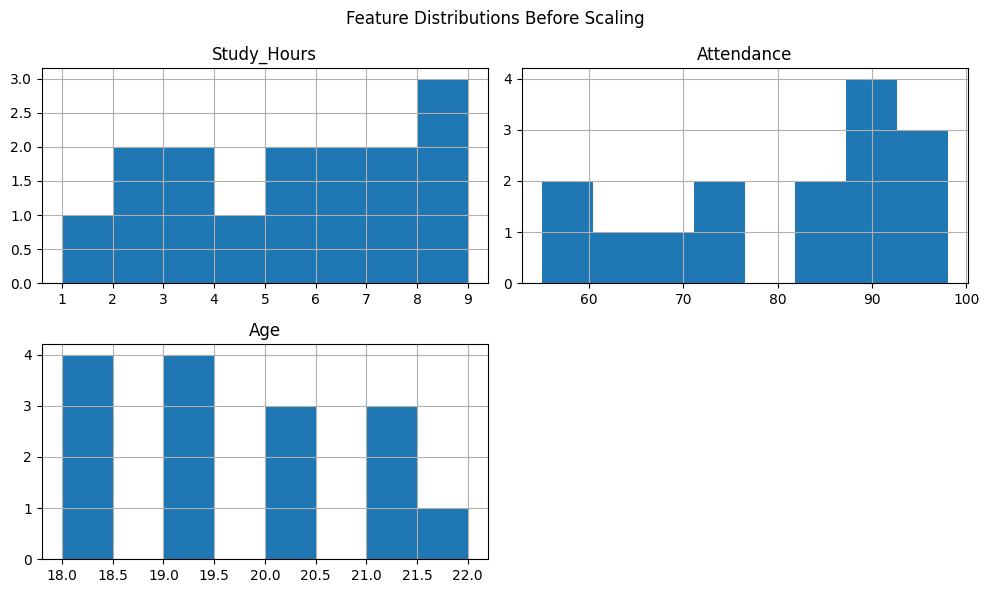

In [7]:
# Plot distributions before scaling

df[numerical_features].hist(figsize=(10, 6), bins=8)

plt.suptitle("Feature Distributions Before Scaling")
plt.tight_layout()
plt.show()

In [8]:
# Apply StandardScaler

standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    df[numerical_features]
)

standard_scaled_df = pd.DataFrame(
    standard_scaled,
    columns=["Study_Hours_Standard", "Attendance_Standard", "Age_Standard"]
)

print("StandardScaler Result:")
display(standard_scaled_df.head())

StandardScaler Result:


,Study_Hours_Standard,Attendance_Standard,Age_Standard
0,-1.273852,-1.570121,-1.218998
1,-0.027692,0.317044,-0.423999
2,-0.858466,-0.815255,-1.218998
3,1.218467,1.071909,0.370999
4,0.387694,0.694476,-0.423999


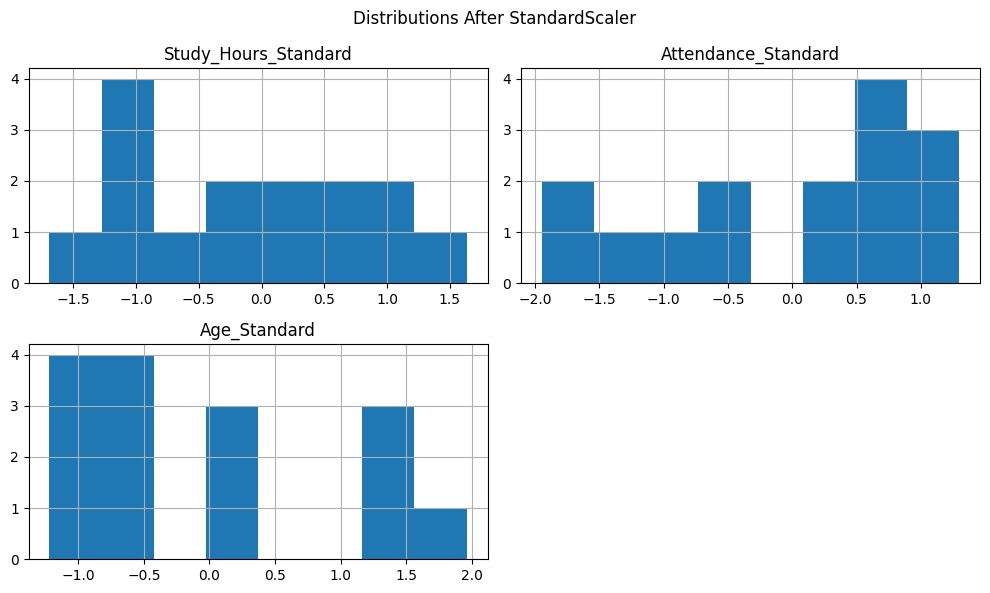

In [9]:
# Distribution after StandardScaler

standard_scaled_df.hist(figsize=(10, 6), bins=8)

plt.suptitle("Distributions After StandardScaler")
plt.tight_layout()
plt.show()

In [10]:
# Apply MinMaxScaler

minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(
    df[numerical_features]
)

minmax_scaled_df = pd.DataFrame(
    minmax_scaled,
    columns=["Study_Hours_MinMax", "Attendance_MinMax", "Age_MinMax"]
)

print("MinMaxScaler Result:")
display(minmax_scaled_df.head())

MinMaxScaler Result:


,Study_Hours_MinMax,Attendance_MinMax,Age_MinMax
0,0.125,0.116279,0.00
1,0.500,0.697674,0.25
2,0.250,0.348837,0.00
3,0.875,0.930233,0.50
4,0.625,0.813953,0.25


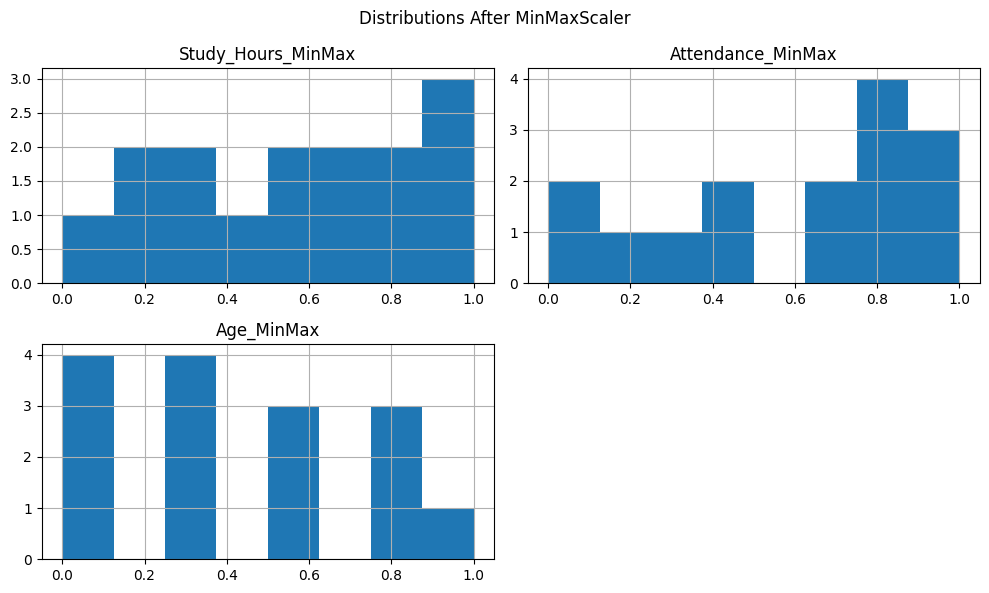

In [11]:
# Distribution after MinMaxScaler

minmax_scaled_df.hist(figsize=(10, 6), bins=8)

plt.suptitle("Distributions After MinMaxScaler")
plt.tight_layout()
plt.show()

In [12]:
# Apply RobustScaler

robust_scaler = RobustScaler()

robust_scaled = robust_scaler.fit_transform(
    df[numerical_features]
)

robust_scaled_df = pd.DataFrame(
    robust_scaled,
    columns=["Study_Hours_Robust", "Attendance_Robust", "Age_Robust"]
)

print("RobustScaler Result:")
display(robust_scaled_df.head())

RobustScaler Result:


,Study_Hours_Robust,Attendance_Robust,Age_Robust
0,-0.75,-1.219512,-0.5
1,0.00,0.000000,0.0
2,-0.50,-0.731707,-0.5
3,0.75,0.487805,0.5
4,0.25,0.243902,0.0


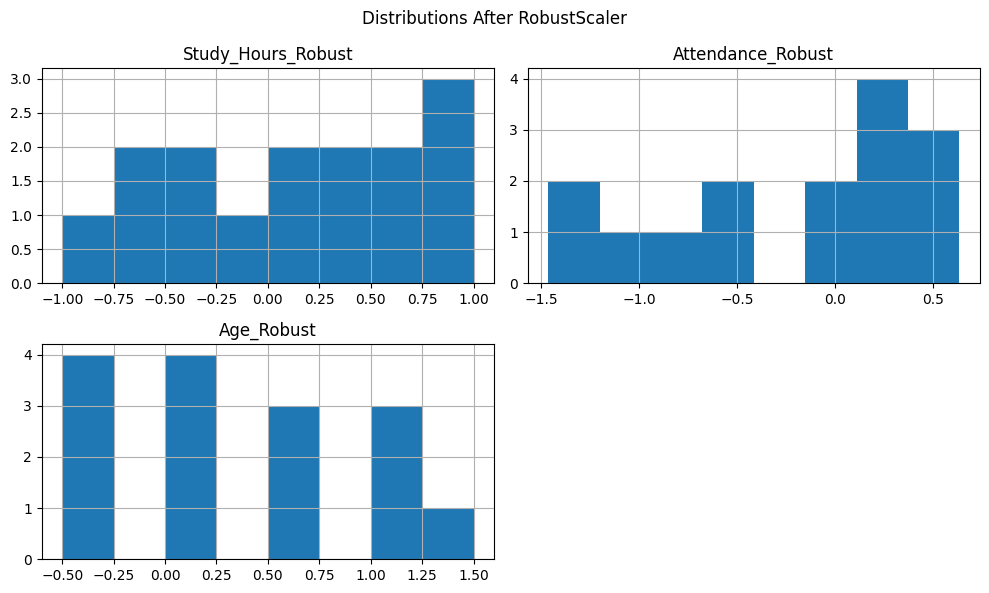

In [13]:
# Distribution after RobustScaler

robust_scaled_df.hist(figsize=(10, 6), bins=8)

plt.suptitle("Distributions After RobustScaler")
plt.tight_layout()
plt.show()

In [14]:
# Prepare features for SelectKBest

# One-hot encoded Department columns
department_encoded_df.index = df.index

# Combine numerical and encoded categorical features
X = pd.concat(
    [
        df[numerical_features],
        df[["Gender_LabelEncoded"]],
        department_encoded_df
    ],
    axis=1
)

# Target variable
y = df["Passed"]

print("Features used for selection:")
display(X.head())

print("Number of features:", X.shape[1])

Features used for selection:


,Study_Hours,Attendance,Age,Gender_LabelEncoded,Department_CSE,Department_ECE,Department_EEE
0,2,60,18,0,1.0,0.0,0.0
1,5,85,19,1,0.0,1.0,0.0
2,3,70,18,0,1.0,0.0,0.0
3,8,95,20,1,0.0,0.0,1.0
4,6,90,19,0,1.0,0.0,0.0


Number of features: 7


In [15]:
# Select the top 5 features

selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top 5 Features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

Top 5 Features:
1. Study_Hours
2. Attendance
3. Age
4. Department_ECE
5. Department_EEE


In [16]:
# Display feature scores

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": selector.scores_,
    "Selected": selector.get_support()
})

feature_scores = feature_scores.sort_values(
    by="F_Score",
    ascending=False
)

display(feature_scores)

,Feature,F_Score,Selected
1,Attendance,4.262614e+01,True
0,Study_Hours,3.166930e+01,True
2,Age,1.666667e+01,True
6,Department_EEE,6.190476e-01,True
5,Department_ECE,5.416667e-01,True
3,Gender_LabelEncoded,1.171171e-01,False
4,Department_CSE,1.603655e-15,False


## Top 5 Features Identified by SelectKBest

SelectKBest with the ANOVA F-test was used to identify the five features
most strongly associated with the target variable `Passed`.

### 1. Attendance
Attendance has the highest F-score (42.626), indicating a strong relationship
with whether a student passed. Students with higher attendance are more likely
to pass.

### 2. Study_Hours
Study_Hours has the second-highest F-score (31.669). This suggests that the
amount of time spent studying is an important factor in predicting student
performance.

### 3. Age
Age has an F-score of 16.667 and was selected among the top five features.
It shows some association with the target variable in this sample dataset.

### 4. Department_EEE
Department_EEE has an F-score of 0.619. It was selected because its score was
higher than the remaining unselected features.

### 5. Department_ECE
Department_ECE has an F-score of 0.542. It was also selected by SelectKBest
as one of the five highest-scoring features.

### Conclusion
Attendance and Study_Hours are the strongest features according to the
ANOVA F-test. Feature selection helps reduce the number of input features
while retaining the features that show the strongest statistical relationship
with the target.